### Imports

In [1]:
import sys
import os

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Running in Google Colab")

    repo_dir = "/content/keyboard_sound"  # fixed absolute path

    if not os.path.exists(repo_dir):
        !git clone https://github.com/ayushma18/keyboard_sound {repo_dir}

    %cd {repo_dir}

    !pip install -r requirements_colab.txt

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import librosa
import os
import random
import seaborn as sns
import pandas as pd
import pickle
import torchaudio
import soundfile as sf

from torchaudio.transforms import TimeMasking, FrequencyMasking
from torchinfo import summary
from tqdm import tqdm
from torchvision import datasets, transforms
from collections import defaultdict
from torchvision.transforms import Compose, ToTensor
from torch.utils.data import DataLoader, Dataset
from scipy.io import wavfile
from sklearn import metrics
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

pd.set_option('future.no_silent_downcasting', True)

/tmp/ipykernel_4899/1340087408.py:28: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.
  pd.set_option('future.no_silent_downcasting', True)


In [3]:
import sys, os
if '.' not in sys.path:
    sys.path.insert(0, '.')

from cnn_shared import (
    NoiseLibrary, AggressiveMultiVariationAugmentation, TimeShifting,
    AudioDataset, TrainingDataset, CNN, init_weights, get_device,
    calculate_rms, add_noise_snr, add_white_noise_snr, add_gaussian_noise_snr, reduce_volume_db,
)
print("✅ Shared classes imported from cnn_shared.py")

✅ Shared classes imported from cnn_shared.py


In [4]:
data_path= "Data/combined/AULA-ALPHANUM"  # Contains 0-9 and a-z (36 classes)
unseen_data_path = "Data/combined/test-alphanum"  # Unseen environment (different person/setup)
noise_path="model/Noises"
best_model_path = f"model/CNN-Best-{data_path.split('/')[-1]}.pkl"
model_path = f"model/CNN-Final-{data_path.split('/')[-1]}.pkl"

### 📌 Dataset Selection

Available datasets in `Data/segmented/`:
- **`alpha-large`** - 26 classes (a-z only)
- **`alphanum-400`** - 36 classes (0-9 and a-z) ✅ **Currently selected**
- **`alphanum-hard-100`** - 36 classes with harder conditions
- **`alphanum-soft-100`** - 36 classes with softer conditions
- **`num-large`** - 10 classes (0-9 only)

Change `data_path` in the cell below to switch datasets.

### Noise Library Loader & Analyzer

In [5]:
# NoiseLibrary class imported from cnn_shared

# Initialize global noise library
print("Initializing Noise Library...")
noise_library = NoiseLibrary(noise_path)
print("✅ Noise Library Ready!\n")

Initializing Noise Library...

✅ Loaded 36 noise samples:
  - city: 3 samples | Avg length: 584.13s | Avg RMS: 0.0678
  - classroom: 13 samples | Avg length: 231.23s | Avg RMS: 0.0599
  - office: 3 samples | Avg length: 285.93s | Avg RMS: 0.0172
  - common: 17 samples | Avg length: 156.71s | Avg RMS: 0.0356
✅ Noise Library Ready!



### SNR-Based Noise Addition Functions

In [6]:
# calculate_rms, add_noise_snr, add_white_noise_snr, add_gaussian_noise_snr,
# and reduce_volume_db are all imported from cnn_shared

### Hybrid Noise Augmentation Pipeline

In [7]:
# AggressiveMultiVariationAugmentation class imported from cnn_shared

# Initialize AGGRESSIVE multi-variation augmentation
print("\n" + "="*70)
print("🔥 INITIALIZING AGGRESSIVE MULTI-VARIATION AUGMENTATION FOR TRAINING")
print("="*70)
aggressive_aug = AggressiveMultiVariationAugmentation(
    noise_library=noise_library,
    snr_range=(0, 30),              # Min 5dB prevents signal cancellation → NaN
    volume_reduction_prob=0.4,
    volume_reduction_range=(2, 15),
    multi_aug_prob=0.6
)
print("="*70 + "\n")


🔥 INITIALIZING AGGRESSIVE MULTI-VARIATION AUGMENTATION FOR TRAINING



### Loading data

In [8]:
# AudioDataset class imported from cnn_shared

In [9]:
# Configure audio loading backend
# In newer torchaudio versions, soundfile is used automatically if installed
# The set_audio_backend API was removed - backends are auto-selected
print("ℹ️  torchaudio will auto-select backend (soundfile is installed)")

sample_rate = 44100
to_mel_spectrogram = torchaudio.transforms.MelSpectrogram(
    sample_rate=44100,
    n_mels=64,
    hop_length=256,
    n_fft=2048,
    win_length=1024,
    f_min=298.97,
    f_max=19569.78,
    power=1.0        # amplitude, not power — important
)
mel_spectrogram_to_numpy = lambda spectrogram: spectrogram.clamp(min=1e-9).log2()[0,:,:].numpy()
transforms = Compose([to_mel_spectrogram, mel_spectrogram_to_numpy, ToTensor()])
dataset = AudioDataset(data_path, None)  # Store raw audio; transforms applied by TrainingDataset
print("number of classes:", dataset.num_classes())


ℹ️  torchaudio will auto-select backend (soundfile is installed)
number of classes: 36


In [10]:
targets = [data[1] for data in dataset]

train_indices, tmp_indices = train_test_split(
    range(len(dataset)),
    test_size=0.2,
    stratify=targets
)

val_indices, test_indices = train_test_split(
    tmp_indices,
    test_size=0.1,
    stratify=[targets[i] for i in tmp_indices]
)

init_train_set = torch.utils.data.Subset(dataset, train_indices)
init_val_set = torch.utils.data.Subset(dataset, val_indices)
init_test_set = torch.utils.data.Subset(dataset, test_indices)

print("Sample rate:", sample_rate)
print(f"Train set size: {len(init_train_set)}, Validation set size: {len(init_val_set)}, Test set size: {len(init_test_set)}")

Sample rate: 44100
Train set size: 6317, Validation set size: 1422, Test set size: 158


### Data Augmentation - AGGRESSIVE Multi-Variation Training


In [11]:
# TrainingDataset class imported from cnn_shared

In [12]:
# TimeShifting class imported from cnn_shared

In [13]:
# 🔥 AGGRESSIVE Multi-Variation Augmentation Pipeline for Hard Training
# Combines: Aggressive Multi-Noise + Time Shifting + HEAVY Spectrogram Masking
# Goal: Force model to learn from MAXIMUM variation (small to large noise)
aug_transforms = Compose([
    aggressive_aug,                  # Apply aggressive multi-variation noise FIRST
    TimeShifting(shift_ratio=0.3),   # Time shifting (50%)
    to_mel_spectrogram,              # Convert to mel spectrogram
    mel_spectrogram_to_numpy,        # Convert to numpy
    ToTensor(),                      # Convert to tensor

    FrequencyMasking(5),             
    #TimeMasking(2),                  # TimeShifting already covers temporal robustness

])

# Training datasets with augmentation and without
train_set = TrainingDataset(init_train_set, aug_transforms)
train_set_no_aug = TrainingDataset(init_train_set, transforms)
val_set = TrainingDataset(init_val_set, transforms)
test_set = TrainingDataset(init_test_set, transforms)

print(f"\n" + "="*70)
print("✅ AGGRESSIVE TRAINING DATASETS CREATED")
print("="*70)
print(f"  ├─ Train (AGGRESSIVE augmentation): {len(train_set)} samples")
print(f"  │   └─ Each sample gets:")
print(f"  │       • One of 9 noise strategies (SNR 0-30dB)")
print(f"  │       • 30% chance of double augmentation")
print(f"  │       • 40% chance of volume reduction")
print(f"  │       • Time shifting (50% range)")
print(f"  │       • 6 layers of spectrogram masking")
print(f"  │")
print(f"  ├─ Train (no augmentation): {len(train_set_no_aug)} samples")
print(f"  ├─ Validation (no augmentation): {len(val_set)} samples")
print(f"  └─ Test (no augmentation): {len(test_set)} samples")
print("="*70)
print("\n💪 Model will be trained on MAXIMUM variation for robustness!")
print("="*70 + "\n")



✅ AGGRESSIVE TRAINING DATASETS CREATED
  ├─ Train (AGGRESSIVE augmentation): 6317 samples
  │   └─ Each sample gets:
  │       • One of 9 noise strategies (SNR 0-30dB)
  │       • 30% chance of double augmentation
  │       • 40% chance of volume reduction
  │       • Time shifting (50% range)
  │       • 6 layers of spectrogram masking
  │
  ├─ Train (no augmentation): 6317 samples
  ├─ Validation (no augmentation): 1422 samples
  └─ Test (no augmentation): 158 samples

💪 Model will be trained on MAXIMUM variation for robustness!



### 🔍 Test Noise Augmentation (Optional - Run to Verify)

In [14]:
# Load a sample waveform for testing noise augmentation
from IPython.display import Audio, display

# Create temp directory if it doesn't exist
temp_audio_dir = '/tmp/noise_samples'
os.makedirs(temp_audio_dir, exist_ok=True)

# Get a sample from the training set (before augmentation)
test_waveform, test_label = init_train_set[0]
print(f"✅ Loaded test sample:")
print(f"   Label index: {test_label.item()}")
print(f"   Waveform shape: {test_waveform.shape}")
print(f"   Sample rate: {sample_rate} Hz")
print(f"   Duration: {test_waveform.shape[1]/sample_rate:.3f} seconds")
print(f"   RMS: {calculate_rms(test_waveform).item():.6f}")

# Save and play original clean audio
clean_audio = test_waveform.numpy()[0] if test_waveform.ndim > 1 else test_waveform.numpy()
clean_path = os.path.join(temp_audio_dir, 'clean_original.wav')
sf.write(clean_path, clean_audio, sample_rate)

print("\n1️⃣  ORIGINAL CLEAN AUDIO")
display(Audio(clean_path, rate=sample_rate))

✅ Loaded test sample:
   Label index: 8
   Waveform shape: torch.Size([1, 18963])
   Sample rate: 44100 Hz
   Duration: 0.430 seconds
   RMS: 0.002746

1️⃣  ORIGINAL CLEAN AUDIO


In [15]:
# 5. Save and play VOLUME REDUCED (simulating far microphone)
volume_reduced_6db = reduce_volume_db(test_waveform, db_reduction=6)
volume_reduced_12db = reduce_volume_db(test_waveform, db_reduction=12)

vol_6db_audio = volume_reduced_6db.numpy()[0] if volume_reduced_6db.ndim > 1 else volume_reduced_6db.numpy()
vol_12db_audio = volume_reduced_12db.numpy()[0] if volume_reduced_12db.ndim > 1 else volume_reduced_12db.numpy()

vol_6db_path = os.path.join(temp_audio_dir, 'volume_reduced_6db.wav')
vol_12db_path = os.path.join(temp_audio_dir, 'volume_reduced_12db.wav')
sf.write(vol_6db_path, vol_6db_audio, sample_rate)
sf.write(vol_12db_path, vol_12db_audio, sample_rate)

print("\n5️⃣  VOLUME REDUCED (Distant Microphone)")
print(f"   🔉 -6 dB reduction - RMS: {calculate_rms(volume_reduced_6db).item():.6f}")
display(Audio(vol_6db_path, rate=sample_rate))
print(f"   🔉 -12 dB reduction - RMS: {calculate_rms(volume_reduced_12db).item():.6f}")
display(Audio(vol_12db_path, rate=sample_rate))


5️⃣  VOLUME REDUCED (Distant Microphone)
   🔉 -6 dB reduction - RMS: 0.001377


   🔉 -12 dB reduction - RMS: 0.000690


In [16]:
# 4. Save and play GAUSSIAN NOISE
gaussian_noise_10db = add_gaussian_noise_snr(test_waveform, target_snr_db=10)
gaussian_noise_5db = add_gaussian_noise_snr(test_waveform, target_snr_db=5)

gaussian_10db_audio = gaussian_noise_10db.numpy()[0] if gaussian_noise_10db.ndim > 1 else gaussian_noise_10db.numpy()
gaussian_5db_audio = gaussian_noise_5db.numpy()[0] if gaussian_noise_5db.ndim > 1 else gaussian_noise_5db.numpy()

gaussian_10db_path = os.path.join(temp_audio_dir, 'gaussian_noise_10db.wav')
gaussian_5db_path = os.path.join(temp_audio_dir, 'gaussian_noise_5db.wav')
sf.write(gaussian_10db_path, gaussian_10db_audio, sample_rate)
sf.write(gaussian_5db_path, gaussian_5db_audio, sample_rate)

print("\n4️⃣  GAUSSIAN NOISE")
print(f"   🔊 Light noise (10 dB SNR) - RMS: {calculate_rms(gaussian_noise_10db).item():.6f}")
display(Audio(gaussian_10db_path, rate=sample_rate))
print(f"   🔊 Heavy noise (5 dB SNR) - RMS: {calculate_rms(gaussian_noise_5db).item():.6f}")
display(Audio(gaussian_5db_path, rate=sample_rate))


4️⃣  GAUSSIAN NOISE
   🔊 Light noise (10 dB SNR) - RMS: 0.002879


   🔊 Heavy noise (5 dB SNR) - RMS: 0.003146


In [17]:
# 3. Save and play WHITE NOISE
white_noise_10db = add_white_noise_snr(test_waveform, target_snr_db=10)
white_noise_5db = add_white_noise_snr(test_waveform, target_snr_db=5)

white_10db_audio = white_noise_10db.numpy()[0] if white_noise_10db.ndim > 1 else white_noise_10db.numpy()
white_5db_audio = white_noise_5db.numpy()[0] if white_noise_5db.ndim > 1 else white_noise_5db.numpy()

white_10db_path = os.path.join(temp_audio_dir, 'white_noise_10db.wav')
white_5db_path = os.path.join(temp_audio_dir, 'white_noise_5db.wav')
sf.write(white_10db_path, white_10db_audio, sample_rate)
sf.write(white_5db_path, white_5db_audio, sample_rate)

print("\n3️⃣  WHITE NOISE (Uniform Random)")
print(f"   🔊 Light noise (10 dB SNR) - RMS: {calculate_rms(white_noise_10db).item():.6f}")
display(Audio(white_10db_path, rate=sample_rate))
print(f"   🔊 Heavy noise (5 dB SNR) - RMS: {calculate_rms(white_noise_5db).item():.6f}")
display(Audio(white_5db_path, rate=sample_rate))


3️⃣  WHITE NOISE (Uniform Random)
   🔊 Light noise (10 dB SNR) - RMS: 0.002883


   🔊 Heavy noise (5 dB SNR) - RMS: 0.003181


In [18]:
# 2. Save and play REAL AMBIENT NOISE (Office/City/Classroom)
# Get noise segments
noise_segment_10db = noise_library.get_noise_segment(test_waveform.shape[1])
noise_segment_5db = noise_library.get_noise_segment(test_waveform.shape[1])

# Check if noise library has samples
if noise_segment_10db is None or noise_segment_5db is None:
    print("\n2️⃣  REAL AMBIENT NOISE (Office/City/Classroom)")
    print("   ⚠️  No noise samples found in the noise library.")
    print(f"   Noise path: {noise_path}")
    print("   Make sure noise files exist in: model/Noises/{city,classroom,office,Common Noises}/")
    print("   Skipping real noise examples...")
else:
    real_noise_10db = add_noise_snr(test_waveform, noise_segment_10db, target_snr_db=10)
    real_noise_5db = add_noise_snr(test_waveform, noise_segment_5db, target_snr_db=5)

    # Convert to numpy
    real_10db_audio = real_noise_10db.numpy()[0] if real_noise_10db.ndim > 1 else real_noise_10db.numpy()
    real_5db_audio = real_noise_5db.numpy()[0] if real_noise_5db.ndim > 1 else real_noise_5db.numpy()

    # Save
    real_10db_path = os.path.join(temp_audio_dir, 'real_ambient_10db.wav')
    real_5db_path = os.path.join(temp_audio_dir, 'real_ambient_5db.wav')
    sf.write(real_10db_path, real_10db_audio, sample_rate)
    sf.write(real_5db_path, real_5db_audio, sample_rate)

    print("\n2️⃣  REAL AMBIENT NOISE (Office/City/Classroom)")
    print(f"   🔊 Light noise (10 dB SNR) - RMS: {calculate_rms(real_noise_10db).item():.6f}")
    display(Audio(real_10db_path, rate=sample_rate))
    print(f"   🔊 Heavy noise (5 dB SNR) - RMS: {calculate_rms(real_noise_5db).item():.6f}")
    display(Audio(real_5db_path, rate=sample_rate))


2️⃣  REAL AMBIENT NOISE (Office/City/Classroom)
   🔊 Light noise (10 dB SNR) - RMS: 0.002880


   🔊 Heavy noise (5 dB SNR) - RMS: 0.003157


### Visualization

torch.Size([64, 75])


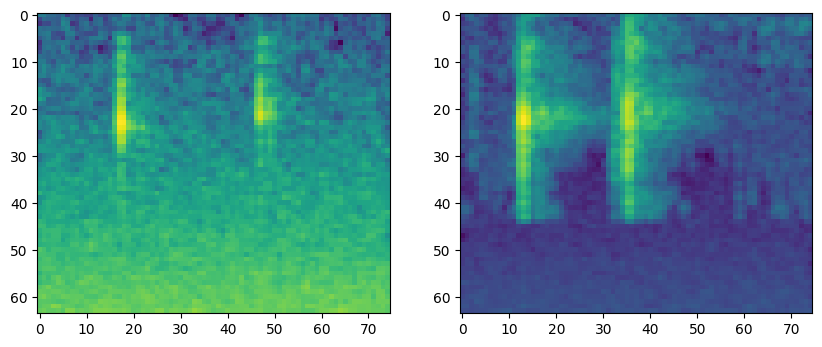

In [19]:
%matplotlib inline
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(train_set[4][0][0], cmap='viridis')
ax2.imshow(val_set[0][0][0], cmap='viridis')
print(train_set[0][0][0].shape)
ax1.grid(False)
ax2.grid(False)
plt.show()

### CNN Model

In [20]:
# ConvBlock class imported from cnn_shared

In [21]:
# CNN class imported from cnn_shared

In [22]:
model = CNN(num_classes=dataset.num_classes())

In [23]:
# init_weights function imported from cnn_shared

In [24]:
# get_device function imported from cnn_shared

device = get_device()

model.apply(init_weights)
model.to(device)

print("Number of parameters: {:,}".format(sum(p.numel() for p in model.parameters())))
print(f"Device: {device}")

summary(model, input_size=(1, 1, 64, 64))

Number of parameters: 4,856,932
Device: cuda


Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 36]                   --
├─ConvBlock: 1-1                         [1, 64, 64, 64]           --
│    └─Sequential: 2-1                   [1, 64, 64, 64]           --
│    │    └─Conv2d: 3-1                  [1, 64, 64, 64]           640
│    │    └─BatchNorm2d: 3-2             [1, 64, 64, 64]           128
│    │    └─ReLU: 3-3                    [1, 64, 64, 64]           --
│    │    └─Conv2d: 3-4                  [1, 64, 64, 64]           36,928
│    │    └─BatchNorm2d: 3-5             [1, 64, 64, 64]           128
│    │    └─ReLU: 3-6                    [1, 64, 64, 64]           --
├─MaxPool2d: 1-2                         [1, 64, 32, 32]           --
├─Dropout2d: 1-3                         [1, 64, 32, 32]           --
├─ConvBlock: 1-4                         [1, 128, 32, 32]          --
│    └─Sequential: 2-2                   [1, 128, 32, 32]          --
│    │  

### Training setup

In [25]:

train_dataloader = torch.utils.data.DataLoader(
    train_set,
    batch_size=32,
    shuffle=True
)

val_dataloader = torch.utils.data.DataLoader(
    val_set,
    batch_size=32,
    shuffle=False
)

test_dataloader = torch.utils.data.DataLoader(
    test_set,
    batch_size=32,
    shuffle=False
)

# Unseen environment — evaluated every epoch to track cross-environment generalisation
unseen_dataset = AudioDataset(unseen_data_path, None)
unseen_set = TrainingDataset(unseen_dataset, transforms)
unseen_dataloader = torch.utils.data.DataLoader(
    unseen_set,
    batch_size=32,
    shuffle=False
)

print(f"✅ Dataloaders ready")
print(f"   Train   : {len(train_set):>5} samples  ({data_path.split('/')[-1]})")
print(f"   Val     : {len(val_set):>5} samples  ({data_path.split('/')[-1]})")
print(f"   Test    : {len(test_set):>5} samples  ({data_path.split('/')[-1]})")
print(f"   Unseen  : {len(unseen_set):>5} samples  ({unseen_data_path.split('/')[-1]})")


✅ Dataloaders ready
   Train   :  6317 samples  (AULA-ALPHANUM)
   Val     :  1422 samples  (AULA-ALPHANUM)
   Test    :   158 samples  (AULA-ALPHANUM)
   Unseen  :   360 samples  (test-alphanum)


In [26]:
cost = nn.CrossEntropyLoss()

learning_rate = 1e-3
weight_decay = 1e-4
max_epochs = 1200  # Maximum epochs (safety limit)

# Early Stopping Parameters
early_stopping_patience = 50  # Stop if no improvement for 50 epochs
early_stopping_min_delta = 0.001  # Minimum change to qualify as improvement

optimizer = optim.Adam(
    model.parameters(), 
    lr=1e-3, 
    weight_decay=1e-4
)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=1e-3,
    epochs=max_epochs,
    steps_per_epoch=len(train_dataloader),
    pct_start=0.1,           # 10% warmup
    anneal_strategy='cos'    # cosine decay
)

### Training

In [27]:

def plot_results(train_losses, train_accuracies, val_losses, val_accuracies, unseen_accuracies=None):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.title("Loss")
    plt.plot(train_losses)
    plt.plot(val_losses)
    plt.legend(["Training loss", "Validation loss"], loc="best")

    plt.subplot(1, 2, 2)
    plt.title("Accuracy")
    plt.plot(train_accuracies)
    plt.plot(val_accuracies)
    legend_labels = ["Training accuracy", "Validation accuracy"]
    if unseen_accuracies is not None:
        plt.plot(unseen_accuracies, linestyle='--', color='orange')
        legend_labels.append("Unseen env accuracy")
    plt.legend(legend_labels, loc="best")
    plt.show()


In [28]:
def save_model(model, path):
    torch.save(model.state_dict(), path)

class EarlyStopping:
    """Early stopping to stop training when validation loss doesn't improve"""
    def __init__(self, patience=50, min_delta=0.001, mode='min'):
        """
        Args:
            patience: Number of epochs to wait after last improvement
            min_delta: Minimum change in monitored metric to qualify as improvement
            mode: 'min' for loss (lower is better), 'max' for accuracy (higher is better)
        """
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.improved = False
        
    def __call__(self, current_score):
        """Check if training should stop"""
        self.improved = False
        
        if self.best_score is None:
            self.best_score = current_score
            self.improved = True
        elif self.mode == 'min':
            if current_score < self.best_score - self.min_delta:
                self.best_score = current_score
                self.counter = 0
                self.improved = True
            else:
                self.counter += 1
        else:  # mode == 'max'
            if current_score > self.best_score + self.min_delta:
                self.best_score = current_score
                self.counter = 0
                self.improved = True
            else:
                self.counter += 1
        
        if self.counter >= self.patience:
            self.early_stop = True
            
        return self.early_stop

🚀 Starting training with early stopping:
   • Max epochs: 1200
   • Early stopping patience: 50 epochs
   • Min delta: 0.001
   • Monitoring: Validation Loss
   • Unseen env: test-alphanum



/tmp/ipykernel_4899/578795210.py:87: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(avg_val_loss)


Epoch [1/1200], Train Loss: 5.0170, Train Acc: 0.0258, Val Loss: 3.5987, Val Acc: 0.0302, Unseen Acc: 0.0222
  ✓ Best model saved with validation accuracy: 0.0302
Epoch [2/1200], Train Loss: 3.9782, Train Acc: 0.0285, Val Loss: 3.5849, Val Acc: 0.0302, Unseen Acc: 0.0472
Epoch [3/1200], Train Loss: 3.8079, Train Acc: 0.0280, Val Loss: 3.5797, Val Acc: 0.0288, Unseen Acc: 0.0556
Epoch [4/1200], Train Loss: 3.7083, Train Acc: 0.0274, Val Loss: 3.5832, Val Acc: 0.0471, Unseen Acc: 0.0111
  ✓ Best model saved with validation accuracy: 0.0471
Epoch [5/1200], Train Loss: 3.6865, Train Acc: 0.0296, Val Loss: 3.5824, Val Acc: 0.0274, Unseen Acc: 0.0083
Epoch [6/1200], Train Loss: 3.6602, Train Acc: 0.0287, Val Loss: 3.5826, Val Acc: 0.0309, Unseen Acc: 0.0278
Epoch [7/1200], Train Loss: 3.6390, Train Acc: 0.0296, Val Loss: 3.5824, Val Acc: 0.0274, Unseen Acc: 0.0250
Epoch [8/1200], Train Loss: 3.6240, Train Acc: 0.0344, Val Loss: 3.5796, Val Acc: 0.0267, Unseen Acc: 0.0333
Epoch [9/1200], Trai

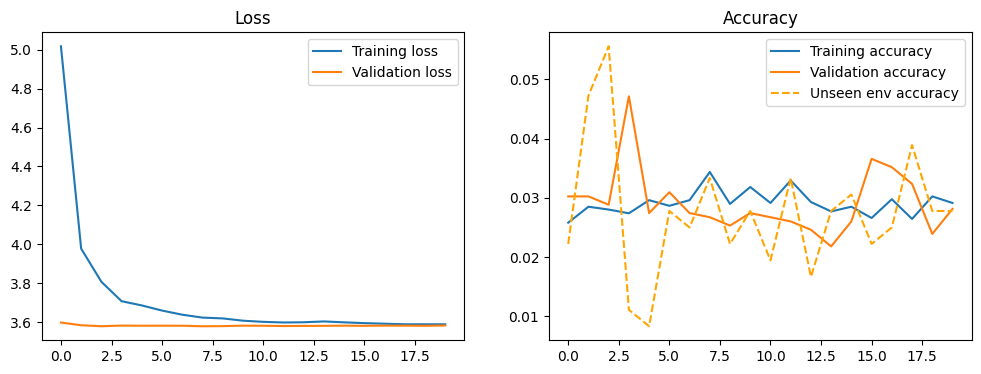

Epoch [21/1200], Train Loss: 3.5864, Train Acc: 0.0299, Val Loss: 3.5830, Val Acc: 0.0316, Unseen Acc: 0.0194
Epoch [22/1200], Train Loss: 3.5891, Train Acc: 0.0269, Val Loss: 3.5835, Val Acc: 0.0401, Unseen Acc: 0.0222
Epoch [23/1200], Train Loss: 3.5859, Train Acc: 0.0294, Val Loss: 3.5833, Val Acc: 0.0281, Unseen Acc: 0.0389
Epoch [24/1200], Train Loss: 3.5875, Train Acc: 0.0287, Val Loss: 3.5833, Val Acc: 0.0359, Unseen Acc: 0.0083
Epoch [25/1200], Train Loss: 3.5871, Train Acc: 0.0310, Val Loss: 3.5837, Val Acc: 0.0274, Unseen Acc: 0.0306
Epoch [26/1200], Train Loss: 3.5857, Train Acc: 0.0253, Val Loss: 3.5834, Val Acc: 0.0359, Unseen Acc: 0.0222
Epoch [27/1200], Train Loss: 3.5860, Train Acc: 0.0291, Val Loss: 3.5829, Val Acc: 0.0309, Unseen Acc: 0.0556
Epoch [28/1200], Train Loss: 3.5858, Train Acc: 0.0288, Val Loss: 3.5822, Val Acc: 0.0373, Unseen Acc: 0.0361
Epoch [29/1200], Train Loss: 3.5859, Train Acc: 0.0275, Val Loss: 3.5801, Val Acc: 0.0302, Unseen Acc: 0.0667
Epoch [30/

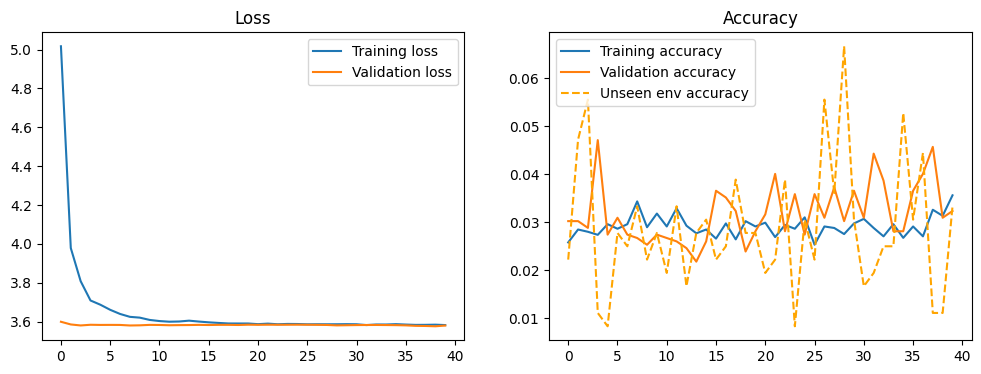

Epoch [41/1200], Train Loss: 3.5817, Train Acc: 0.0291, Val Loss: 3.5720, Val Acc: 0.0401, Unseen Acc: 0.0528
Epoch [42/1200], Train Loss: 3.5806, Train Acc: 0.0283, Val Loss: 3.5740, Val Acc: 0.0436, Unseen Acc: 0.0361
Epoch [43/1200], Train Loss: 3.5774, Train Acc: 0.0313, Val Loss: 3.5698, Val Acc: 0.0380, Unseen Acc: 0.0417
Epoch [44/1200], Train Loss: 3.5797, Train Acc: 0.0275, Val Loss: 3.5665, Val Acc: 0.0387, Unseen Acc: 0.0194
Epoch [45/1200], Train Loss: 3.5754, Train Acc: 0.0339, Val Loss: 3.5684, Val Acc: 0.0429, Unseen Acc: 0.0556
Epoch [46/1200], Train Loss: 3.5804, Train Acc: 0.0321, Val Loss: 3.5614, Val Acc: 0.0338, Unseen Acc: 0.0444
Epoch [47/1200], Train Loss: 3.5729, Train Acc: 0.0313, Val Loss: 3.5583, Val Acc: 0.0394, Unseen Acc: 0.0333
Epoch [48/1200], Train Loss: 3.5769, Train Acc: 0.0358, Val Loss: 3.5644, Val Acc: 0.0570, Unseen Acc: 0.0278
  ✓ Best model saved with validation accuracy: 0.0570
Epoch [49/1200], Train Loss: 3.5729, Train Acc: 0.0351, Val Loss: 

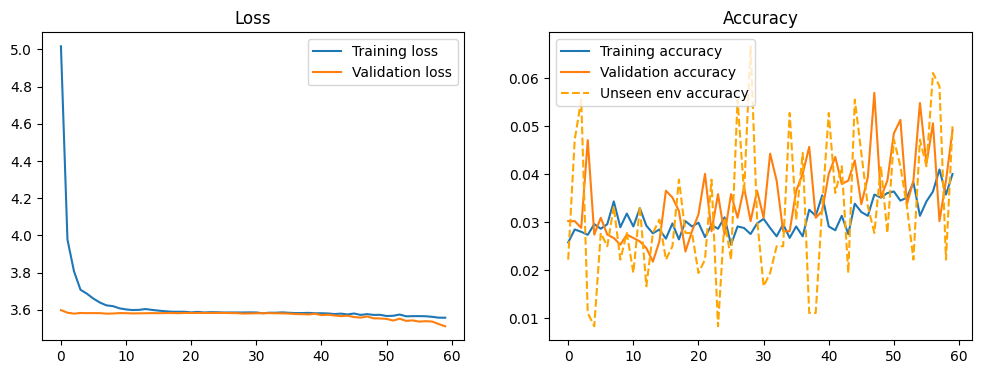

Epoch [61/1200], Train Loss: 3.5542, Train Acc: 0.0380, Val Loss: 3.5033, Val Acc: 0.0429, Unseen Acc: 0.0500
Epoch [62/1200], Train Loss: 3.5545, Train Acc: 0.0355, Val Loss: 3.5264, Val Acc: 0.0443, Unseen Acc: 0.0444
Epoch [63/1200], Train Loss: 3.5493, Train Acc: 0.0378, Val Loss: 3.5152, Val Acc: 0.0506, Unseen Acc: 0.0528
Epoch [64/1200], Train Loss: 3.5456, Train Acc: 0.0374, Val Loss: 3.5139, Val Acc: 0.0366, Unseen Acc: 0.0472
Epoch [65/1200], Train Loss: 3.5466, Train Acc: 0.0388, Val Loss: 3.5035, Val Acc: 0.0570, Unseen Acc: 0.0444
Epoch [66/1200], Train Loss: 3.5438, Train Acc: 0.0404, Val Loss: 3.4991, Val Acc: 0.0591, Unseen Acc: 0.0389
  ✓ Best model saved with validation accuracy: 0.0591
Epoch [67/1200], Train Loss: 3.5385, Train Acc: 0.0415, Val Loss: 3.4985, Val Acc: 0.0471, Unseen Acc: 0.0639
Epoch [68/1200], Train Loss: 3.5351, Train Acc: 0.0391, Val Loss: 3.4868, Val Acc: 0.0626, Unseen Acc: 0.0361
  ✓ Best model saved with validation accuracy: 0.0626
Epoch [69/12

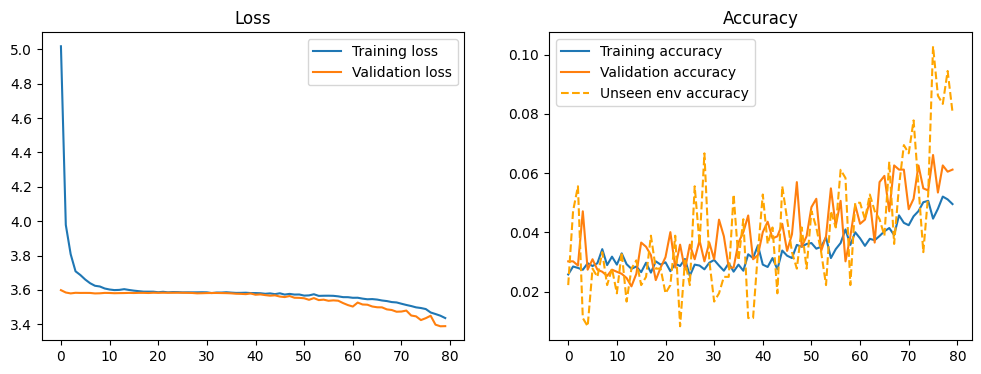

Epoch [81/1200], Train Loss: 3.4309, Train Acc: 0.0503, Val Loss: 3.3234, Val Acc: 0.0668, Unseen Acc: 0.0861
  ✓ Best model saved with validation accuracy: 0.0668
Epoch [82/1200], Train Loss: 3.4161, Train Acc: 0.0502, Val Loss: 3.3263, Val Acc: 0.0647, Unseen Acc: 0.0861
Epoch [83/1200], Train Loss: 3.3970, Train Acc: 0.0562, Val Loss: 3.2957, Val Acc: 0.0654, Unseen Acc: 0.0722
Epoch [84/1200], Train Loss: 3.3875, Train Acc: 0.0497, Val Loss: 3.2523, Val Acc: 0.0689, Unseen Acc: 0.0694
  ✓ Best model saved with validation accuracy: 0.0689
Epoch [85/1200], Train Loss: 3.3741, Train Acc: 0.0624, Val Loss: 3.2897, Val Acc: 0.0731, Unseen Acc: 0.0694
  ✓ Best model saved with validation accuracy: 0.0731
Epoch [86/1200], Train Loss: 3.3644, Train Acc: 0.0619, Val Loss: 3.2321, Val Acc: 0.0738, Unseen Acc: 0.0694
  ✓ Best model saved with validation accuracy: 0.0738
Epoch [87/1200], Train Loss: 3.3434, Train Acc: 0.0608, Val Loss: 3.2347, Val Acc: 0.0696, Unseen Acc: 0.0639
Epoch [88/1200

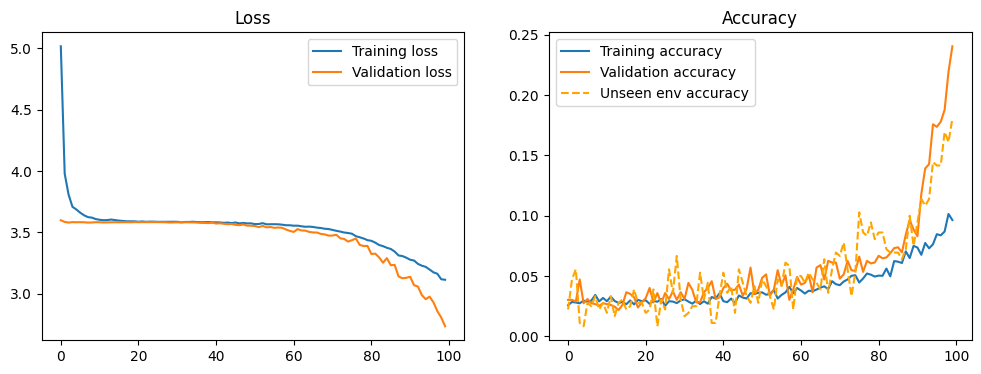

  ✓ Best model saved with validation accuracy: 0.2405
Epoch [101/1200], Train Loss: 3.0897, Train Acc: 0.1088, Val Loss: 2.7797, Val Acc: 0.2363, Unseen Acc: 0.1639
Epoch [102/1200], Train Loss: 3.0539, Train Acc: 0.1118, Val Loss: 2.6395, Val Acc: 0.2686, Unseen Acc: 0.1833
  ✓ Best model saved with validation accuracy: 0.2686
Epoch [103/1200], Train Loss: 3.0218, Train Acc: 0.1133, Val Loss: 2.6584, Val Acc: 0.2736, Unseen Acc: 0.1722
  ✓ Best model saved with validation accuracy: 0.2736
Epoch [104/1200], Train Loss: 2.9993, Train Acc: 0.1225, Val Loss: 2.5475, Val Acc: 0.2883, Unseen Acc: 0.2111
  ✓ Best model saved with validation accuracy: 0.2883
Epoch [105/1200], Train Loss: 2.9704, Train Acc: 0.1259, Val Loss: 2.5325, Val Acc: 0.2940, Unseen Acc: 0.2333
  ✓ Best model saved with validation accuracy: 0.2940
Epoch [106/1200], Train Loss: 2.9327, Train Acc: 0.1388, Val Loss: 2.4840, Val Acc: 0.3221, Unseen Acc: 0.2389
  ✓ Best model saved with validation accuracy: 0.3221
Epoch [107

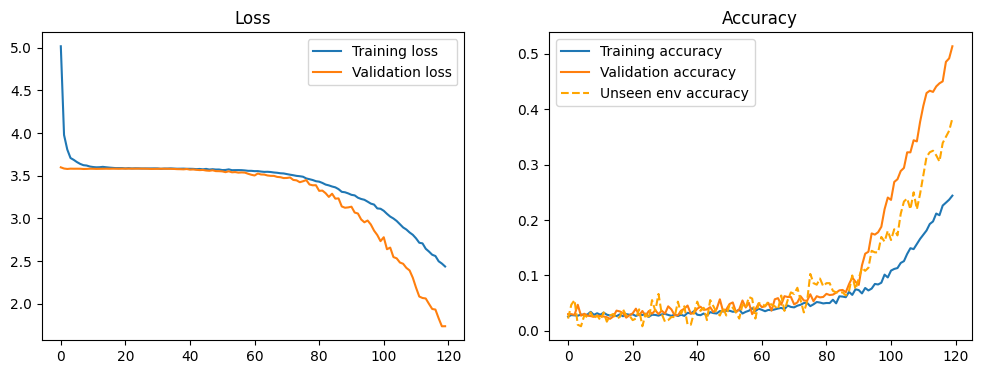

  ✓ Best model saved with validation accuracy: 0.5134
Epoch [121/1200], Train Loss: 2.4074, Train Acc: 0.2481, Val Loss: 1.6863, Val Acc: 0.5274, Unseen Acc: 0.3778
  ✓ Best model saved with validation accuracy: 0.5274
Epoch [122/1200], Train Loss: 2.3481, Train Acc: 0.2678, Val Loss: 1.6397, Val Acc: 0.5169, Unseen Acc: 0.3639
Epoch [123/1200], Train Loss: 2.3341, Train Acc: 0.2718, Val Loss: 1.6079, Val Acc: 0.5323, Unseen Acc: 0.3583
  ✓ Best model saved with validation accuracy: 0.5323
Epoch [124/1200], Train Loss: 2.2843, Train Acc: 0.2849, Val Loss: 1.5503, Val Acc: 0.5485, Unseen Acc: 0.3750
  ✓ Best model saved with validation accuracy: 0.5485
Epoch [125/1200], Train Loss: 2.2116, Train Acc: 0.3088, Val Loss: 1.5289, Val Acc: 0.5534, Unseen Acc: 0.3861
  ✓ Best model saved with validation accuracy: 0.5534
Epoch [126/1200], Train Loss: 2.2215, Train Acc: 0.3019, Val Loss: 1.4043, Val Acc: 0.5809, Unseen Acc: 0.3972
  ✓ Best model saved with validation accuracy: 0.5809
Epoch [127

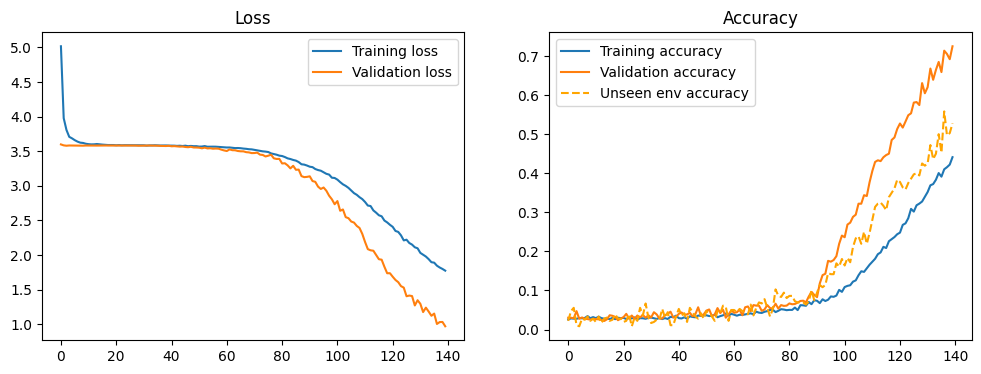

  ✓ Best model saved with validation accuracy: 0.7250
Epoch [141/1200], Train Loss: 1.7111, Train Acc: 0.4491, Val Loss: 0.8594, Val Acc: 0.7546, Unseen Acc: 0.5556
  ✓ Best model saved with validation accuracy: 0.7546
Epoch [142/1200], Train Loss: 1.6978, Train Acc: 0.4520, Val Loss: 0.9397, Val Acc: 0.7328, Unseen Acc: 0.5222
Epoch [143/1200], Train Loss: 1.6606, Train Acc: 0.4722, Val Loss: 0.8845, Val Acc: 0.7475, Unseen Acc: 0.5389
Epoch [144/1200], Train Loss: 1.6637, Train Acc: 0.4687, Val Loss: 0.9045, Val Acc: 0.7342, Unseen Acc: 0.5194
Epoch [145/1200], Train Loss: 1.6235, Train Acc: 0.4785, Val Loss: 0.7934, Val Acc: 0.7651, Unseen Acc: 0.5722
  ✓ Best model saved with validation accuracy: 0.7651
Epoch [146/1200], Train Loss: 1.5990, Train Acc: 0.4931, Val Loss: 0.8201, Val Acc: 0.7644, Unseen Acc: 0.5639
Epoch [147/1200], Train Loss: 1.5534, Train Acc: 0.4996, Val Loss: 0.7630, Val Acc: 0.7813, Unseen Acc: 0.5500
  ✓ Best model saved with validation accuracy: 0.7813
Epoch [

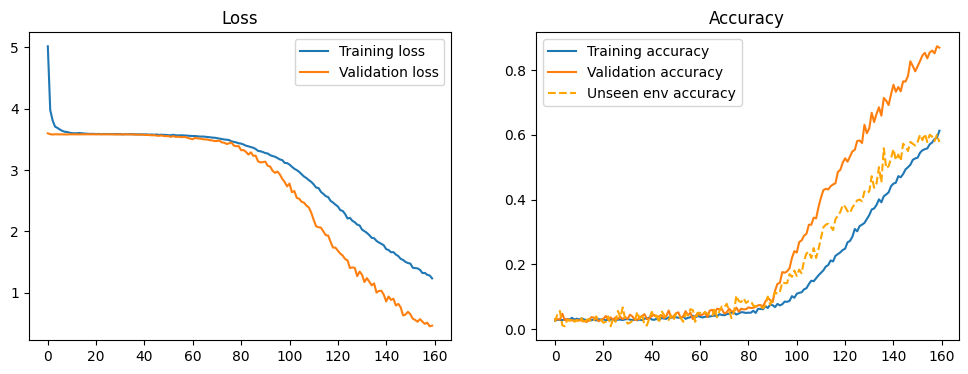

Epoch [161/1200], Train Loss: 1.2268, Train Acc: 0.6125, Val Loss: 0.4087, Val Acc: 0.8896, Unseen Acc: 0.6028
  ✓ Best model saved with validation accuracy: 0.8896
Epoch [162/1200], Train Loss: 1.2010, Train Acc: 0.6171, Val Loss: 0.3969, Val Acc: 0.8896, Unseen Acc: 0.6083
Epoch [163/1200], Train Loss: 1.1637, Train Acc: 0.6255, Val Loss: 0.3641, Val Acc: 0.9001, Unseen Acc: 0.6222
  ✓ Best model saved with validation accuracy: 0.9001
Epoch [164/1200], Train Loss: 1.1752, Train Acc: 0.6232, Val Loss: 0.3793, Val Acc: 0.8966, Unseen Acc: 0.6333
Epoch [165/1200], Train Loss: 1.1311, Train Acc: 0.6492, Val Loss: 0.3432, Val Acc: 0.9093, Unseen Acc: 0.6194
  ✓ Best model saved with validation accuracy: 0.9093
Epoch [166/1200], Train Loss: 1.1015, Train Acc: 0.6524, Val Loss: 0.3325, Val Acc: 0.9191, Unseen Acc: 0.6167
  ✓ Best model saved with validation accuracy: 0.9191
Epoch [167/1200], Train Loss: 1.1088, Train Acc: 0.6570, Val Loss: 0.3807, Val Acc: 0.8896, Unseen Acc: 0.6278
Epoch [

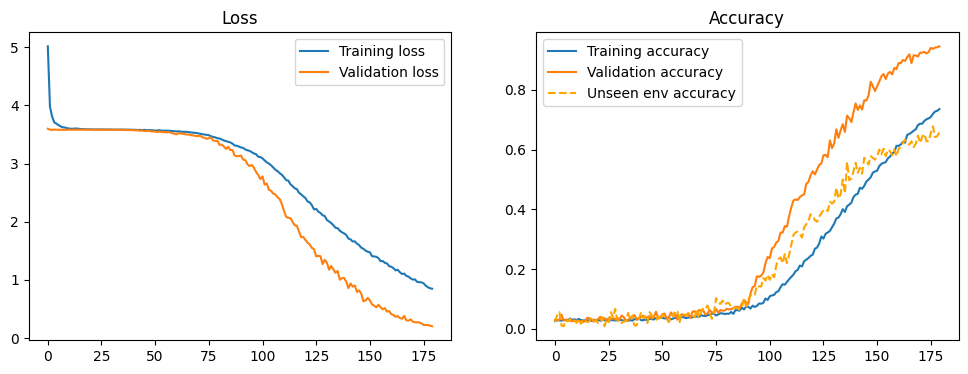

  ✓ Best model saved with validation accuracy: 0.9459
Epoch [181/1200], Train Loss: 0.8479, Train Acc: 0.7364, Val Loss: 0.2126, Val Acc: 0.9423, Unseen Acc: 0.6806
Epoch [182/1200], Train Loss: 0.8365, Train Acc: 0.7428, Val Loss: 0.2021, Val Acc: 0.9423, Unseen Acc: 0.6917
Epoch [183/1200], Train Loss: 0.8482, Train Acc: 0.7394, Val Loss: 0.1875, Val Acc: 0.9522, Unseen Acc: 0.6500
  ✓ Best model saved with validation accuracy: 0.9522
Epoch [184/1200], Train Loss: 0.8272, Train Acc: 0.7447, Val Loss: 0.1812, Val Acc: 0.9494, Unseen Acc: 0.6750
Epoch [185/1200], Train Loss: 0.7944, Train Acc: 0.7595, Val Loss: 0.1952, Val Acc: 0.9423, Unseen Acc: 0.6917
Epoch [186/1200], Train Loss: 0.7828, Train Acc: 0.7580, Val Loss: 0.1693, Val Acc: 0.9557, Unseen Acc: 0.6611
  ✓ Best model saved with validation accuracy: 0.9557
Epoch [187/1200], Train Loss: 0.7744, Train Acc: 0.7572, Val Loss: 0.1747, Val Acc: 0.9515, Unseen Acc: 0.6889
Epoch [188/1200], Train Loss: 0.7676, Train Acc: 0.7618, Val 

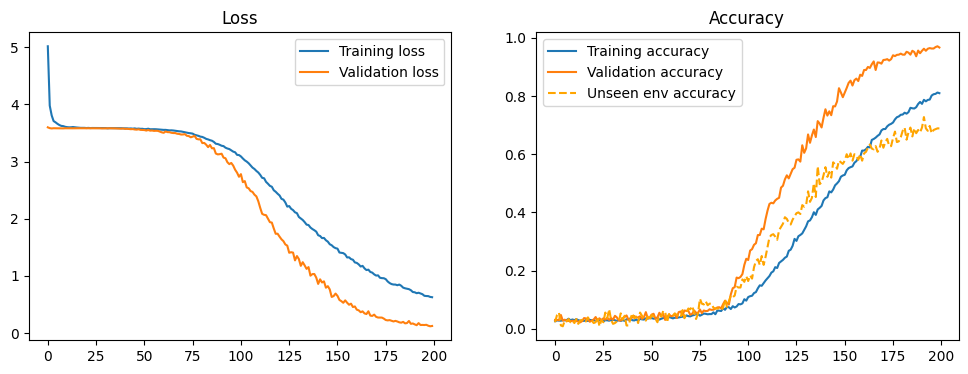

Epoch [201/1200], Train Loss: 0.5964, Train Acc: 0.8219, Val Loss: 0.1149, Val Acc: 0.9684, Unseen Acc: 0.7250
Epoch [202/1200], Train Loss: 0.6260, Train Acc: 0.8116, Val Loss: 0.1120, Val Acc: 0.9705, Unseen Acc: 0.7028
Epoch [203/1200], Train Loss: 0.5839, Train Acc: 0.8240, Val Loss: 0.1269, Val Acc: 0.9691, Unseen Acc: 0.6889
Epoch [204/1200], Train Loss: 0.5819, Train Acc: 0.8180, Val Loss: 0.1001, Val Acc: 0.9754, Unseen Acc: 0.7139
  ✓ Best model saved with validation accuracy: 0.9754
Epoch [205/1200], Train Loss: 0.5811, Train Acc: 0.8295, Val Loss: 0.1128, Val Acc: 0.9684, Unseen Acc: 0.6917
Epoch [206/1200], Train Loss: 0.5736, Train Acc: 0.8243, Val Loss: 0.0946, Val Acc: 0.9775, Unseen Acc: 0.7472
  ✓ Best model saved with validation accuracy: 0.9775
Epoch [207/1200], Train Loss: 0.5452, Train Acc: 0.8349, Val Loss: 0.0941, Val Acc: 0.9775, Unseen Acc: 0.7194
Epoch [208/1200], Train Loss: 0.5487, Train Acc: 0.8259, Val Loss: 0.1002, Val Acc: 0.9726, Unseen Acc: 0.6639
Epoc

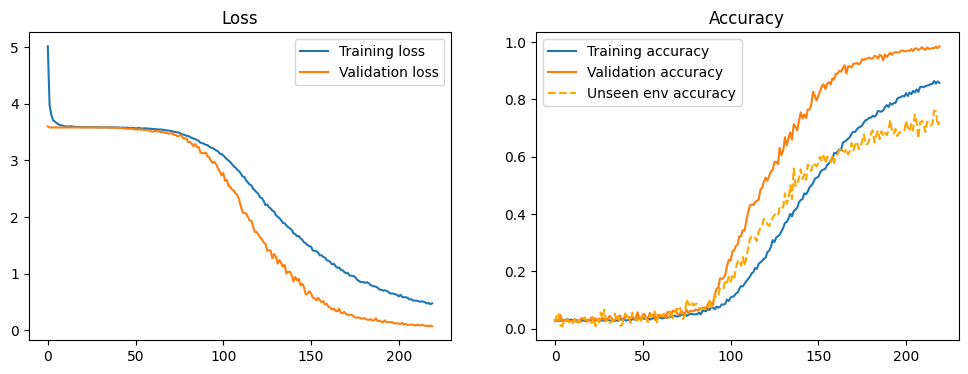

  ✓ Best model saved with validation accuracy: 0.9852
Epoch [221/1200], Train Loss: 0.4497, Train Acc: 0.8675, Val Loss: 0.0758, Val Acc: 0.9789, Unseen Acc: 0.7361
Epoch [222/1200], Train Loss: 0.4526, Train Acc: 0.8686, Val Loss: 0.0820, Val Acc: 0.9754, Unseen Acc: 0.7250
Epoch [223/1200], Train Loss: 0.4582, Train Acc: 0.8705, Val Loss: 0.0690, Val Acc: 0.9838, Unseen Acc: 0.7389
Epoch [224/1200], Train Loss: 0.4359, Train Acc: 0.8746, Val Loss: 0.0626, Val Acc: 0.9838, Unseen Acc: 0.7444
Epoch [225/1200], Train Loss: 0.4281, Train Acc: 0.8716, Val Loss: 0.0649, Val Acc: 0.9838, Unseen Acc: 0.7444
Epoch [226/1200], Train Loss: 0.4402, Train Acc: 0.8678, Val Loss: 0.0701, Val Acc: 0.9796, Unseen Acc: 0.7417
Epoch [227/1200], Train Loss: 0.4099, Train Acc: 0.8789, Val Loss: 0.0661, Val Acc: 0.9817, Unseen Acc: 0.6944
Epoch [228/1200], Train Loss: 0.4204, Train Acc: 0.8762, Val Loss: 0.0648, Val Acc: 0.9810, Unseen Acc: 0.7167
Epoch [229/1200], Train Loss: 0.4237, Train Acc: 0.8762, V

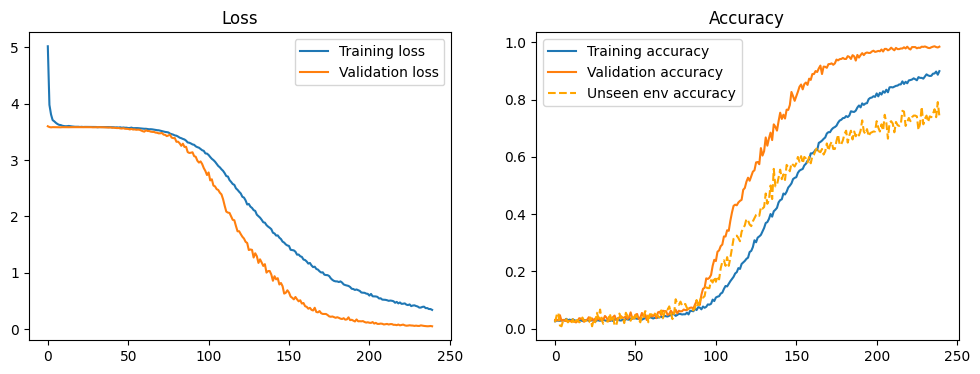

Epoch [241/1200], Train Loss: 0.3624, Train Acc: 0.8928, Val Loss: 0.0539, Val Acc: 0.9838, Unseen Acc: 0.7500
Epoch [242/1200], Train Loss: 0.3233, Train Acc: 0.9055, Val Loss: 0.0459, Val Acc: 0.9852, Unseen Acc: 0.7889
Epoch [243/1200], Train Loss: 0.3401, Train Acc: 0.8976, Val Loss: 0.0485, Val Acc: 0.9859, Unseen Acc: 0.7611
Epoch [244/1200], Train Loss: 0.3448, Train Acc: 0.8965, Val Loss: 0.0470, Val Acc: 0.9873, Unseen Acc: 0.7472
  ✓ Best model saved with validation accuracy: 0.9873
Epoch [245/1200], Train Loss: 0.3334, Train Acc: 0.8998, Val Loss: 0.0534, Val Acc: 0.9852, Unseen Acc: 0.7278
Epoch [246/1200], Train Loss: 0.3456, Train Acc: 0.9000, Val Loss: 0.0498, Val Acc: 0.9873, Unseen Acc: 0.7639
Epoch [247/1200], Train Loss: 0.3154, Train Acc: 0.9121, Val Loss: 0.0459, Val Acc: 0.9866, Unseen Acc: 0.7556
Epoch [248/1200], Train Loss: 0.3149, Train Acc: 0.9120, Val Loss: 0.0448, Val Acc: 0.9880, Unseen Acc: 0.7639
  ✓ Best model saved with validation accuracy: 0.9880
Epoc

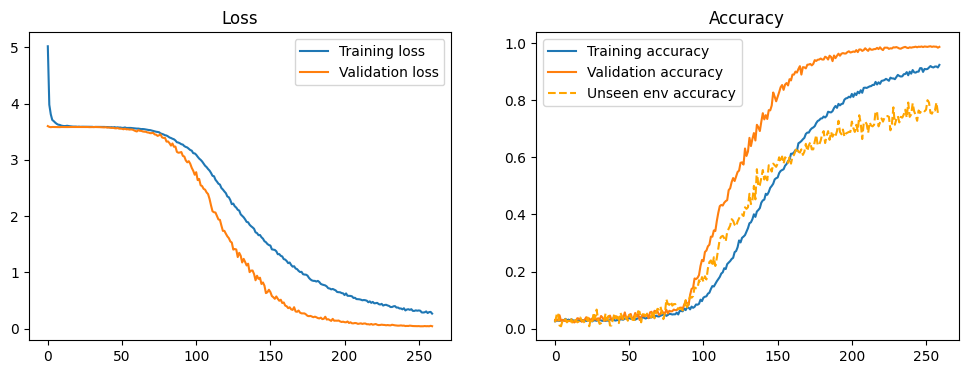

Epoch [261/1200], Train Loss: 0.2816, Train Acc: 0.9156, Val Loss: 0.0484, Val Acc: 0.9852, Unseen Acc: 0.7389
Epoch [262/1200], Train Loss: 0.2719, Train Acc: 0.9186, Val Loss: 0.0425, Val Acc: 0.9895, Unseen Acc: 0.7667
  ✓ Best model saved with validation accuracy: 0.9895
Epoch [263/1200], Train Loss: 0.2822, Train Acc: 0.9223, Val Loss: 0.0390, Val Acc: 0.9895, Unseen Acc: 0.7611
Epoch [264/1200], Train Loss: 0.2757, Train Acc: 0.9216, Val Loss: 0.0446, Val Acc: 0.9866, Unseen Acc: 0.7694
Epoch [265/1200], Train Loss: 0.2687, Train Acc: 0.9234, Val Loss: 0.0459, Val Acc: 0.9866, Unseen Acc: 0.7750
Epoch [266/1200], Train Loss: 0.2515, Train Acc: 0.9318, Val Loss: 0.0385, Val Acc: 0.9902, Unseen Acc: 0.8139
  ✓ Best model saved with validation accuracy: 0.9902
Epoch [267/1200], Train Loss: 0.2719, Train Acc: 0.9232, Val Loss: 0.0372, Val Acc: 0.9895, Unseen Acc: 0.7944
Epoch [268/1200], Train Loss: 0.2735, Train Acc: 0.9224, Val Loss: 0.0377, Val Acc: 0.9895, Unseen Acc: 0.7750
Epoc

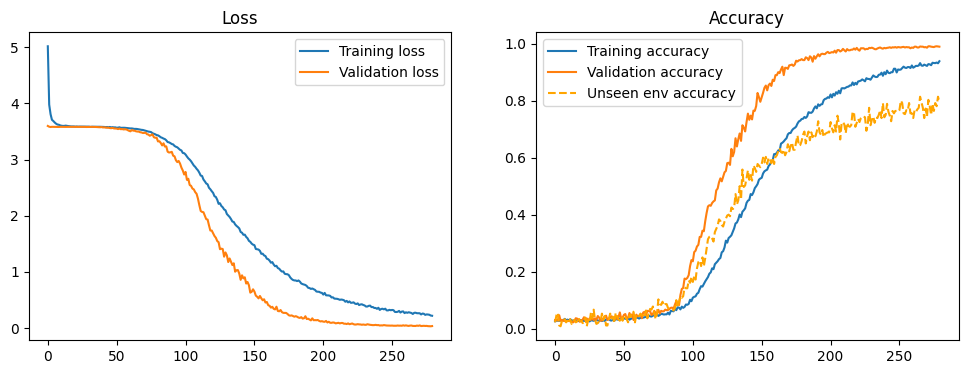

Epoch [281/1200], Train Loss: 0.2287, Train Acc: 0.9379, Val Loss: 0.0304, Val Acc: 0.9916, Unseen Acc: 0.7944
  ✓ Best model saved with validation accuracy: 0.9916
Epoch [282/1200], Train Loss: 0.2167, Train Acc: 0.9381, Val Loss: 0.0369, Val Acc: 0.9902, Unseen Acc: 0.7806
Epoch [283/1200], Train Loss: 0.2398, Train Acc: 0.9280, Val Loss: 0.0349, Val Acc: 0.9895, Unseen Acc: 0.7778
Epoch [284/1200], Train Loss: 0.2167, Train Acc: 0.9391, Val Loss: 0.0339, Val Acc: 0.9902, Unseen Acc: 0.7639
Epoch [285/1200], Train Loss: 0.2157, Train Acc: 0.9364, Val Loss: 0.0343, Val Acc: 0.9895, Unseen Acc: 0.7611
Epoch [286/1200], Train Loss: 0.2065, Train Acc: 0.9436, Val Loss: 0.0316, Val Acc: 0.9895, Unseen Acc: 0.8028
Epoch [287/1200], Train Loss: 0.2153, Train Acc: 0.9386, Val Loss: 0.0354, Val Acc: 0.9887, Unseen Acc: 0.7583
Epoch [288/1200], Train Loss: 0.2128, Train Acc: 0.9410, Val Loss: 0.0327, Val Acc: 0.9902, Unseen Acc: 0.7667
Epoch [289/1200], Train Loss: 0.2210, Train Acc: 0.9392, V

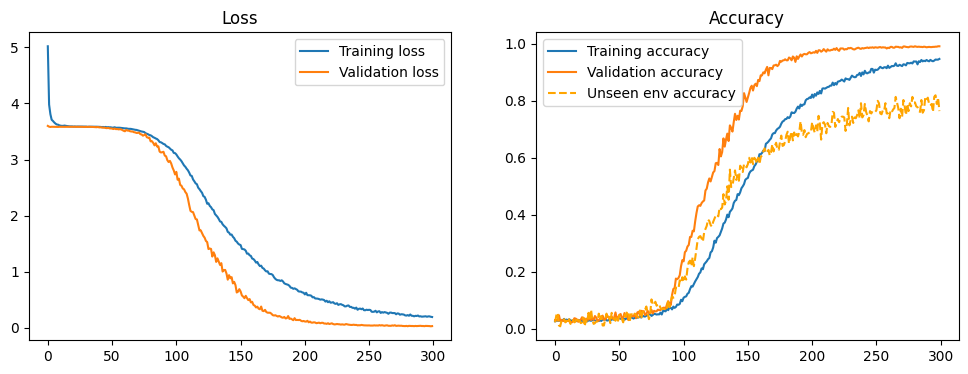

Epoch [301/1200], Train Loss: 0.1917, Train Acc: 0.9474, Val Loss: 0.0344, Val Acc: 0.9909, Unseen Acc: 0.7806
Epoch [302/1200], Train Loss: 0.2051, Train Acc: 0.9424, Val Loss: 0.0345, Val Acc: 0.9895, Unseen Acc: 0.7778
Epoch [303/1200], Train Loss: 0.1917, Train Acc: 0.9470, Val Loss: 0.0336, Val Acc: 0.9902, Unseen Acc: 0.7944
Epoch [304/1200], Train Loss: 0.1890, Train Acc: 0.9441, Val Loss: 0.0299, Val Acc: 0.9909, Unseen Acc: 0.7556
Epoch [305/1200], Train Loss: 0.1788, Train Acc: 0.9524, Val Loss: 0.0301, Val Acc: 0.9909, Unseen Acc: 0.8139
Epoch [306/1200], Train Loss: 0.1826, Train Acc: 0.9498, Val Loss: 0.0288, Val Acc: 0.9916, Unseen Acc: 0.7917
Epoch [307/1200], Train Loss: 0.1840, Train Acc: 0.9479, Val Loss: 0.0329, Val Acc: 0.9902, Unseen Acc: 0.7556
Epoch [308/1200], Train Loss: 0.1917, Train Acc: 0.9452, Val Loss: 0.0284, Val Acc: 0.9923, Unseen Acc: 0.7972
  ✓ Best model saved with validation accuracy: 0.9923
Epoch [309/1200], Train Loss: 0.1741, Train Acc: 0.9528, V

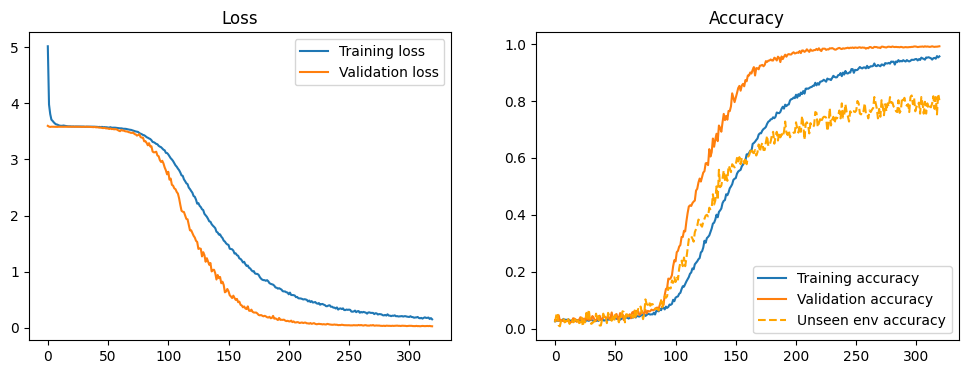

Epoch [321/1200], Train Loss: 0.1546, Train Acc: 0.9539, Val Loss: 0.0255, Val Acc: 0.9916, Unseen Acc: 0.8361
Epoch [322/1200], Train Loss: 0.1511, Train Acc: 0.9565, Val Loss: 0.0246, Val Acc: 0.9930, Unseen Acc: 0.7972
  ✓ Best model saved with validation accuracy: 0.9930
Epoch [323/1200], Train Loss: 0.1495, Train Acc: 0.9568, Val Loss: 0.0314, Val Acc: 0.9923, Unseen Acc: 0.7583
Epoch [324/1200], Train Loss: 0.1682, Train Acc: 0.9478, Val Loss: 0.0268, Val Acc: 0.9930, Unseen Acc: 0.8028
Epoch [325/1200], Train Loss: 0.1601, Train Acc: 0.9554, Val Loss: 0.0254, Val Acc: 0.9930, Unseen Acc: 0.8083
Epoch [326/1200], Train Loss: 0.1570, Train Acc: 0.9582, Val Loss: 0.0276, Val Acc: 0.9930, Unseen Acc: 0.8222
Epoch [327/1200], Train Loss: 0.1581, Train Acc: 0.9544, Val Loss: 0.0288, Val Acc: 0.9923, Unseen Acc: 0.8167
Epoch [328/1200], Train Loss: 0.1459, Train Acc: 0.9590, Val Loss: 0.0307, Val Acc: 0.9909, Unseen Acc: 0.8222
Epoch [329/1200], Train Loss: 0.1471, Train Acc: 0.9576, V

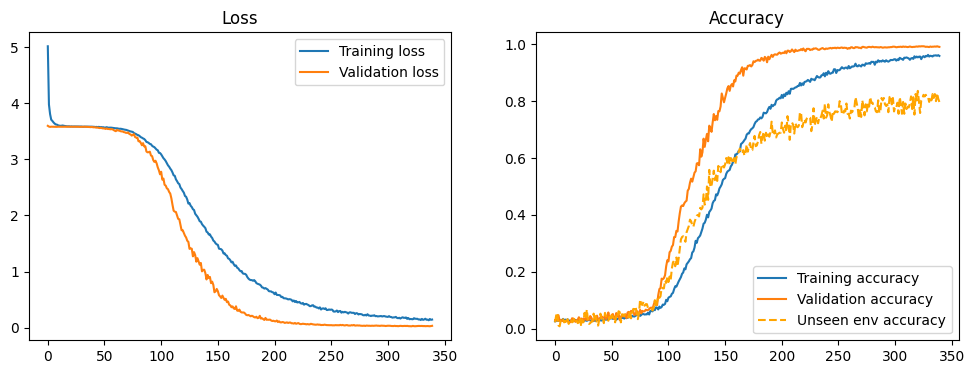

Epoch [341/1200], Train Loss: 0.1382, Train Acc: 0.9601, Val Loss: 0.0275, Val Acc: 0.9916, Unseen Acc: 0.7861
Epoch [342/1200], Train Loss: 0.1348, Train Acc: 0.9599, Val Loss: 0.0252, Val Acc: 0.9916, Unseen Acc: 0.8028
Epoch [343/1200], Train Loss: 0.1492, Train Acc: 0.9588, Val Loss: 0.0269, Val Acc: 0.9930, Unseen Acc: 0.8139
Epoch [344/1200], Train Loss: 0.1369, Train Acc: 0.9628, Val Loss: 0.0301, Val Acc: 0.9916, Unseen Acc: 0.8056
Epoch [345/1200], Train Loss: 0.1374, Train Acc: 0.9599, Val Loss: 0.0288, Val Acc: 0.9916, Unseen Acc: 0.8139
Epoch [346/1200], Train Loss: 0.1356, Train Acc: 0.9630, Val Loss: 0.0294, Val Acc: 0.9923, Unseen Acc: 0.8306
Epoch [347/1200], Train Loss: 0.1374, Train Acc: 0.9647, Val Loss: 0.0270, Val Acc: 0.9923, Unseen Acc: 0.8417
Epoch [348/1200], Train Loss: 0.1247, Train Acc: 0.9644, Val Loss: 0.0261, Val Acc: 0.9923, Unseen Acc: 0.8028
Epoch [349/1200], Train Loss: 0.1285, Train Acc: 0.9617, Val Loss: 0.0268, Val Acc: 0.9909, Unseen Acc: 0.8111
E

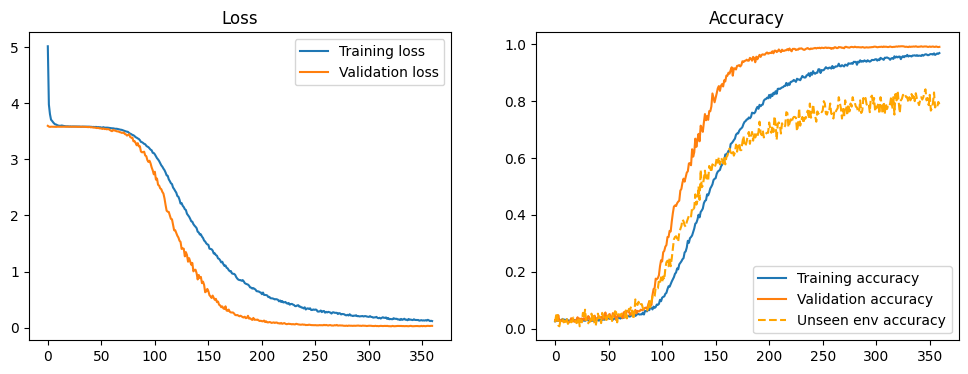

Epoch [361/1200], Train Loss: 0.1412, Train Acc: 0.9599, Val Loss: 0.0302, Val Acc: 0.9909, Unseen Acc: 0.7722
Epoch [362/1200], Train Loss: 0.1176, Train Acc: 0.9679, Val Loss: 0.0286, Val Acc: 0.9916, Unseen Acc: 0.8056
Epoch [363/1200], Train Loss: 0.1125, Train Acc: 0.9701, Val Loss: 0.0277, Val Acc: 0.9923, Unseen Acc: 0.7944
Epoch [364/1200], Train Loss: 0.1031, Train Acc: 0.9715, Val Loss: 0.0294, Val Acc: 0.9923, Unseen Acc: 0.7917
Epoch [365/1200], Train Loss: 0.1124, Train Acc: 0.9675, Val Loss: 0.0289, Val Acc: 0.9916, Unseen Acc: 0.7972
Epoch [366/1200], Train Loss: 0.1254, Train Acc: 0.9661, Val Loss: 0.0290, Val Acc: 0.9923, Unseen Acc: 0.8000
Epoch [367/1200], Train Loss: 0.1204, Train Acc: 0.9649, Val Loss: 0.0313, Val Acc: 0.9916, Unseen Acc: 0.8139
Epoch [368/1200], Train Loss: 0.1135, Train Acc: 0.9664, Val Loss: 0.0297, Val Acc: 0.9930, Unseen Acc: 0.8250
Epoch [369/1200], Train Loss: 0.1177, Train Acc: 0.9682, Val Loss: 0.0287, Val Acc: 0.9923, Unseen Acc: 0.8222
E

In [29]:

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
unseen_accuracies = []
best_val_acc = 0.0

# Initialize early stopping
early_stopping = EarlyStopping(patience=early_stopping_patience, 
                                min_delta=early_stopping_min_delta, 
                                mode='min')  # Monitor validation loss

print(f"🚀 Starting training with early stopping:")
print(f"   • Max epochs: {max_epochs}")
print(f"   • Early stopping patience: {early_stopping_patience} epochs")
print(f"   • Min delta: {early_stopping_min_delta}")
print(f"   • Monitoring: Validation Loss")
print(f"   • Unseen env: {unseen_data_path.split('/')[-1]}\n")

for epoch in range(max_epochs):
    model.train()
    correct = 0
    total = 0
    epoch_loss = 0

    for inputs, labels in train_dataloader:
        inputs = inputs.to(device)
        labels = torch.squeeze(labels).to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        loss = cost(outputs, labels)

        loss.backward()
        optimizer.step()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        epoch_loss += loss.item()

    train_acc = correct / total
    avg_train_loss = epoch_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    with torch.no_grad():
        # ── Validation ────────────────────────────────────────────────────────
        correct = 0
        total = 0
        val_loss = 0

        for inputs, labels in val_dataloader:
            inputs = inputs.to(device)
            labels = torch.squeeze(labels).to(device)
            outputs = model(inputs)

            loss = cost(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        val_acc = correct / total
        avg_val_loss = val_loss / len(val_dataloader)
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        # ── Unseen environment ────────────────────────────────────────────────
        unseen_correct = 0
        unseen_total = 0

        for inputs, labels in unseen_dataloader:
            inputs = inputs.to(device)
            labels = torch.squeeze(labels).to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            unseen_total += labels.size(0)
            unseen_correct += (predicted == labels).sum().item()

        unseen_acc = unseen_correct / unseen_total
        unseen_accuracies.append(unseen_acc)

    scheduler.step(avg_val_loss)

    print(f"Epoch [{epoch + 1}/{max_epochs}], "
          f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}, "
          f"Unseen Acc: {unseen_acc:.4f}")

    if epoch != 0 and (epoch % 20 == 19):
        plot_results(train_losses, train_accuracies, val_losses, val_accuracies, unseen_accuracies)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_model(model, best_model_path)
        print(f"  ✓ Best model saved with validation accuracy: {val_acc:.4f}")

    # Early stopping check
    if early_stopping(avg_val_loss):
        print(f"\n🛑 Early stopping triggered after {epoch + 1} epochs")
        print(f"   • No improvement in validation loss for {early_stopping.patience} epochs")
        print(f"   • Best validation loss: {early_stopping.best_score:.4f}")
        print(f"   • Best validation accuracy: {best_val_acc:.4f}")
        break

# Final summary
if not early_stopping.early_stop:
    print(f"\n✅ Training completed - reached maximum epochs ({max_epochs})")
else:
    print(f"\n✅ Training completed - early stopping at epoch {epoch + 1}")

print(f"   • Total epochs trained  : {len(train_losses)}")
print(f"   • Best validation acc   : {best_val_acc:.4f}")
print(f"   • Final validation acc  : {val_accuracies[-1]:.4f}")
print(f"   • Final unseen env acc  : {unseen_accuracies[-1]:.4f}")


In [30]:
save_model(model, model_path)

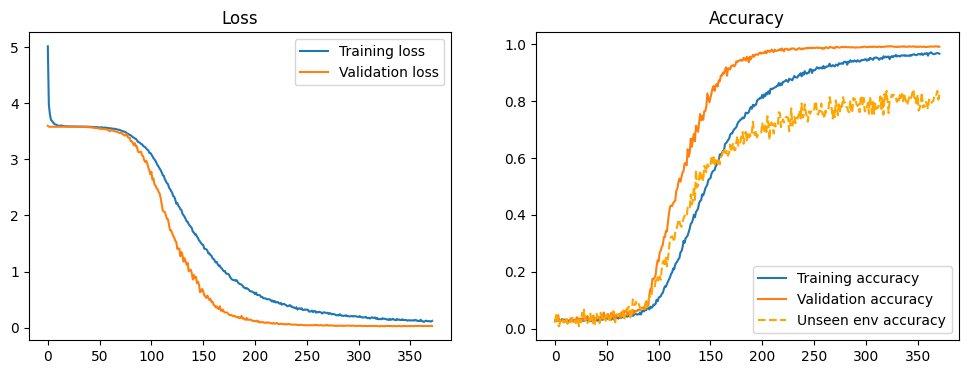


📊 Training Summary:
   • Best validation acc   : 0.9930
   • Last validation acc   : 0.9916
   • Last unseen env acc   : 0.8250
   • Epochs trained        : 372


In [31]:

# Plot final training results
plot_results(train_losses, train_accuracies, val_losses, val_accuracies, unseen_accuracies)

print(f"\n📊 Training Summary:")
print(f"   • Best validation acc   : {max(val_accuracies):.4f}")
print(f"   • Last validation acc   : {val_accuracies[-1]:.4f}")
print(f"   • Last unseen env acc   : {unseen_accuracies[-1]:.4f}")
print(f"   • Epochs trained        : {len(val_accuracies)}")


---

## 🔧 Fine-Tuning

For fine-tuning a trained model on production/deployment data, use:

**[CNN-FineTuning.ipynb](CNN-FineTuning.ipynb)**

This separate notebook allows you to:
- Load a pre-trained model from this notebook
- Fine-tune on small production datasets  
- Freeze early layers for better performance on small data
- Compare original vs fine-tuned model accuracy

---

### Results

In [32]:
model.load_state_dict(torch.load(best_model_path))
model.to(device)
model.eval()

CNN(
  (conv1): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout2d(p=0.25, inplace=False)
  (conv2): ConvBlock(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=

In [33]:
digits = [str(digit) for digit in range(10)]
alphabet = [chr(ascii_code) for ascii_code in range(ord('A'), ord('Z') + 1)]
all_characters = digits + alphabet
label_dict = {i: all_characters[i] for i in range(len(all_characters))}
print(label_dict)

{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'A', 11: 'B', 12: 'C', 13: 'D', 14: 'E', 15: 'F', 16: 'G', 17: 'H', 18: 'I', 19: 'J', 20: 'K', 21: 'L', 22: 'M', 23: 'N', 24: 'O', 25: 'P', 26: 'Q', 27: 'R', 28: 'S', 29: 'T', 30: 'U', 31: 'V', 32: 'W', 33: 'X', 34: 'Y', 35: 'Z'}


In [34]:
def predict(data_loader):
    original_labels = []
    predicted_labels = []
    correct = 0
    total = 0

    model.eval()

    for inputs, labels in data_loader:
        inputs = inputs.to(device)
        labels = torch.squeeze(labels).to(device)
        outputs = model(inputs)

        _, predicted = torch.max(outputs.data, 1)

        original_labels.extend(labels.cpu().numpy())
        predicted_labels.extend(predicted.cpu().numpy())

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    prediction_df = pd.DataFrame({
        "predicted_labels": [label_dict[pred] for pred in predicted_labels],
        "true_labels": [label_dict[label] for label in original_labels]
    })

    print(f"Test Accuracy: {correct/total}")
    pd.set_option('display.max_rows', None)
    pd.set_option("display.max_columns", None)
    display(prediction_df.T)

    print(metrics.accuracy_score(original_labels, predicted_labels))
    print(metrics.classification_report(original_labels, predicted_labels))

    return confusion_matrix(original_labels, predicted_labels)

### Test accuracy

In [35]:
cm = predict(test_dataloader)

Test Accuracy: 0.9936708860759493


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157
predicted_labels,V,D,M,I,S,S,8,A,B,X,Z,S,T,3,F,K,6,3,6,4,R,Y,E,D,2,B,E,U,K,X,L,O,T,W,T,3,Z,2,I,5,J,D,G,9,B,L,P,N,2,O,E,T,S,V,E,N,9,A,2,N,U,C,P,6,R,F,U,A,1,E,W,U,6,K,C,7,O,H,4,8,X,H,J,C,J,B,H,Q,Y,8,F,6,V,P,Z,Q,K,O,U,C,R,7,F,5,3,7,L,R,Y,N,0,8,5,I,4,U,L,W,0,M,F,Y,M,N,W,G,M,Z,G,V,Q,M,3,5,Y,A,5,2,G,1,0,X,I,9,T,K,H,0,9,Q,D,P,4,7,J,1,B,C
true_labels,V,D,M,I,S,S,8,A,B,X,Z,S,T,3,F,K,6,3,6,4,R,Y,E,D,2,B,E,1,K,X,L,O,T,W,T,3,Z,2,I,5,J,D,G,9,B,L,P,N,2,O,E,T,S,V,E,N,9,A,2,N,U,C,P,6,R,F,U,A,1,E,W,U,6,K,C,7,O,H,4,8,X,H,J,C,J,B,H,Q,Y,8,F,6,V,P,Z,Q,K,O,U,C,R,7,F,5,3,7,L,R,Y,N,0,8,5,I,4,U,L,W,0,M,F,Y,M,N,W,G,M,Z,G,V,Q,M,3,5,Y,A,5,2,G,1,0,X,I,9,T,K,H,0,9,Q,D,P,4,7,J,1,B,C


0.9936708860759493
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      0.75      0.86         4
           2       1.00      1.00      1.00         5
           3       1.00      1.00      1.00         5
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         5
           6       1.00      1.00      1.00         5
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00         4
           9       1.00      1.00      1.00         4
          10       1.00      1.00      1.00         4
          11       1.00      1.00      1.00         5
          12       1.00      1.00      1.00         5
          13       1.00      1.00      1.00         4
          14       1.00      1.00      1.00         5
          15       1.00      1.00      1.00         5
          16       1.00      1.00      1.00         4
        

### Confusion matrix

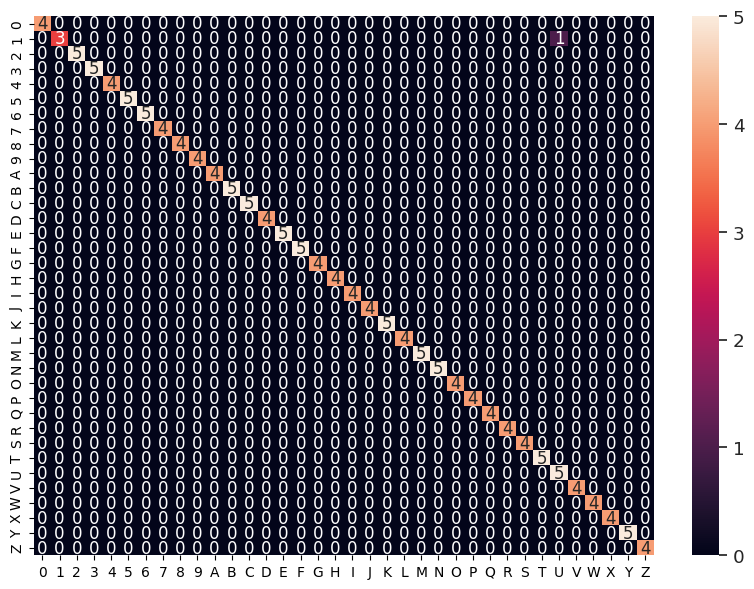

In [36]:
fig, ax = plt.subplots(figsize=(10,7))
sns.set(font_scale=1.2)
ax = sns.heatmap(cm,
                annot=True,
                fmt='g',
                xticklabels=all_characters,
                yticklabels=all_characters,
                annot_kws={"size": 12}
                )
plt.show()

---

## 🎙️ Gradio Web Interface

Interactive web interface for testing the trained model with real audio recordings or uploaded files.

In [37]:
import sys
import os
best_model_path = "model/CNN-Best.pkl"
# Add inference module to path
inference_path = os.path.join(os.getcwd(), 'inference')
if inference_path not in sys.path:
    sys.path.insert(0, inference_path)

from app_gradio import create_gradio_interface

# Create the Gradio interface with the best model
interface = create_gradio_interface(model_path=best_model_path)

print("✅ Gradio interface created successfully!")
print(f"   Model: {best_model_path}")

/root/minor/keyboard_sound/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Loading model from: model/CNN-Best.pkl
Device: CUDA
⚠ Warning: Unknown model type, defaulting to CNN
First 5 keys: ['conv1.conv.0.weight', 'conv1.conv.0.bias', 'conv1.conv.1.weight', 'conv1.conv.1.bias', 'conv1.conv.1.running_mean']
Creating CNN model with 36 classes...
Using alphanumeric labels (0-9, a-z)
Model parameters: 4,856,932
Model test successful - output shape: torch.Size([1, 36])
✓ Model loaded successfully!

✅ Gradio interface created successfully!
   Model: model/CNN-Best.pkl


In [38]:
# Launch the Gradio interface
# Options:
#   share=True  : Create a public shareable link (requires internet)
#   share=False : Local access only (default)
#   server_port=7860 : Specify a custom port

print("\n🚀 Launching Gradio web interface...")
print("   Once launched, the interface will be available at the URL shown below.")
print("   Use it to test the model with real-time audio recording or file uploads.\n")

# Launch with auto-reload disabled in notebook environment
interface.launch(
    share=True,
    inline=False,  # Display inline in Jupyter notebook
    quiet=True,   # Suppress Gradio logs for cleaner output
)


🚀 Launching Gradio web interface...
   Once launched, the interface will be available at the URL shown below.
   Use it to test the model with real-time audio recording or file uploads.

* Running on public URL: https://257878a082a9cbf429.gradio.live
